In [1]:
# Cell 1: Upload dataset
from google.colab import files
uploaded = files.upload()

Saving sales_data.csv to sales_data.csv


In [2]:
# Cell 2: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")
print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Cell 3: Load dataset
df = pd.read_csv("sales_data.csv")

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [4]:
# Cell 4: Explore dataset
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (100, 7)

Columns:
Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')

Data Types:
Date           object
Product        object
Quantity        int64
Price           int64
Customer_ID    object
Region         object
Total_Sales     int64
dtype: object

Missing Values:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64


In [5]:
# Cell 5: Clean and prepare data
df = df.drop_duplicates()

df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

print("Data cleaned successfully")
df.head()

Data cleaned successfully


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Month,Year
0,2024-01-01,Phone,7,37300,CUST001,East,261100,1,2024
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,1,2024
2,2024-01-03,Phone,2,21746,CUST003,West,43492,1,2024
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,1,2024
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,1,2024


In [6]:
# Cell 6: Basic sales metrics
total_revenue = df["Total_Sales"].sum()
average_sales = df["Total_Sales"].mean()
best_product = df.groupby("Product")["Total_Sales"].sum().idxmax()
best_region = df.groupby("Region")["Total_Sales"].sum().idxmax()

print("Total Revenue:", total_revenue)
print("Average Sales:", average_sales)
print("Best Product:", best_product)
print("Best Region:", best_region)

Total Revenue: 12365048
Average Sales: 123650.48
Best Product: Laptop
Best Region: North


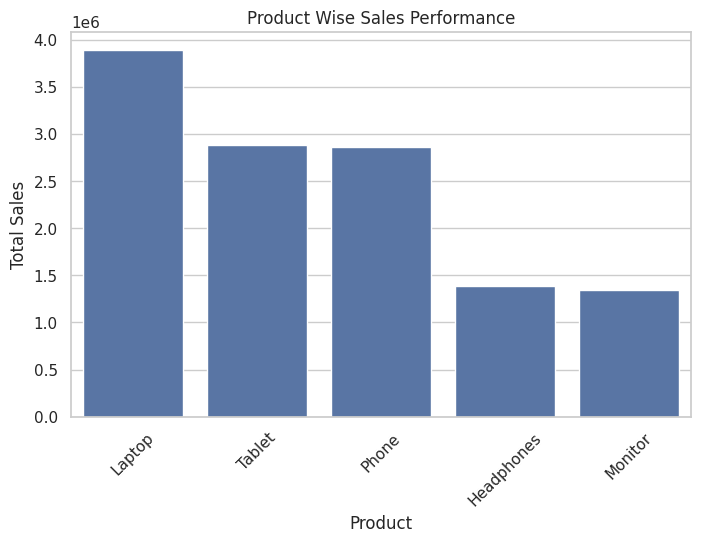

In [7]:
# Cell 7: Bar chart - Product wise sales
plt.figure(figsize=(8, 5))
product_sales = df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)

sns.barplot(x=product_sales.index, y=product_sales.values)

plt.title("Product Wise Sales Performance")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

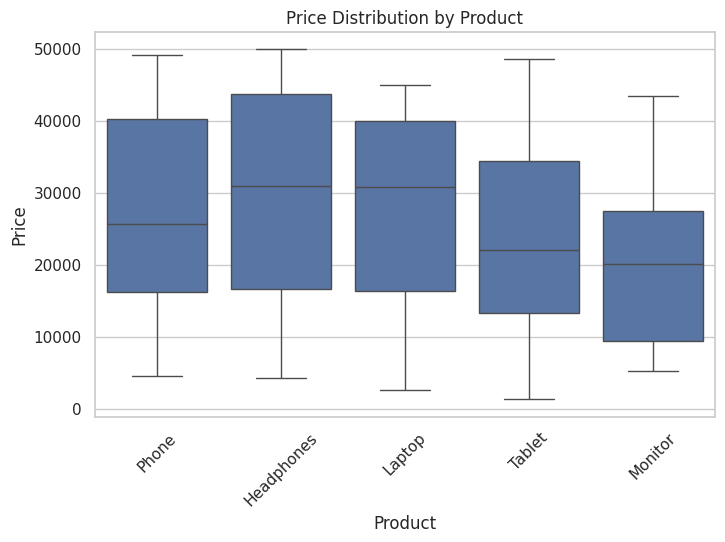

In [8]:
# Cell 8: Box plot - Price distribution by product
plt.figure(figsize=(8, 5))

sns.boxplot(x="Product", y="Price", data=df)

plt.title("Price Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

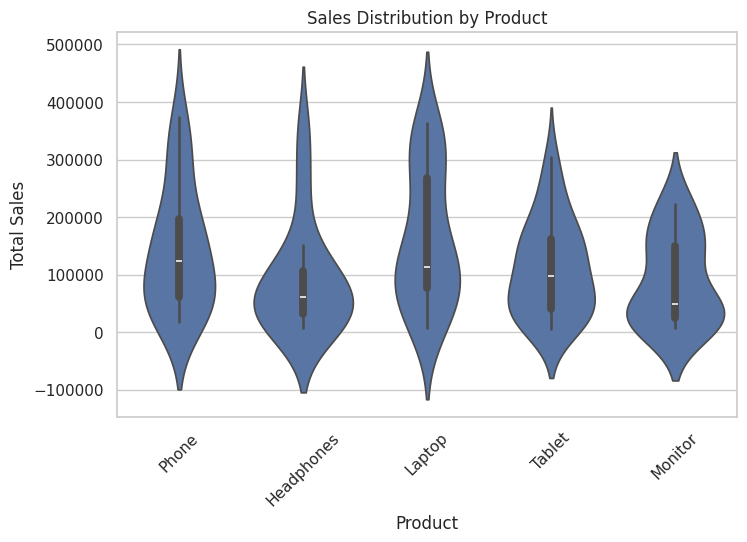

In [9]:
# Cell 9: Violin plot - Sales distribution by product
plt.figure(figsize=(8, 5))

sns.violinplot(x="Product", y="Total_Sales", data=df)

plt.title("Sales Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

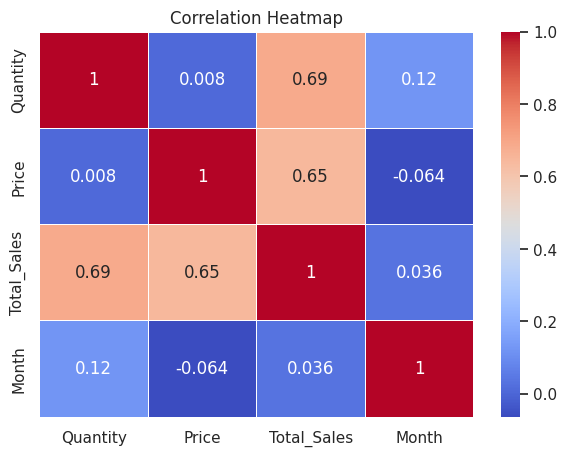

In [10]:
# Cell 10: Correlation heatmap
numeric_df = df[["Quantity", "Price", "Total_Sales", "Month"]]

plt.figure(figsize=(7, 5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

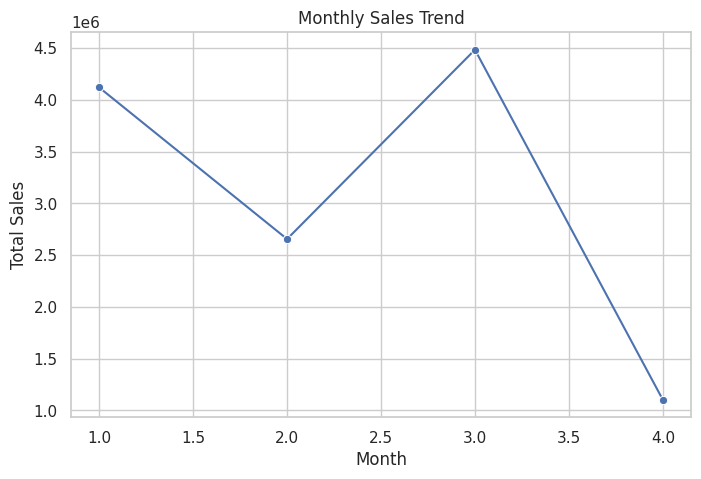

In [11]:
# Cell 11: Line chart - Monthly sales trend
monthly_sales = df.groupby("Month")["Total_Sales"].sum()

plt.figure(figsize=(8, 5))

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

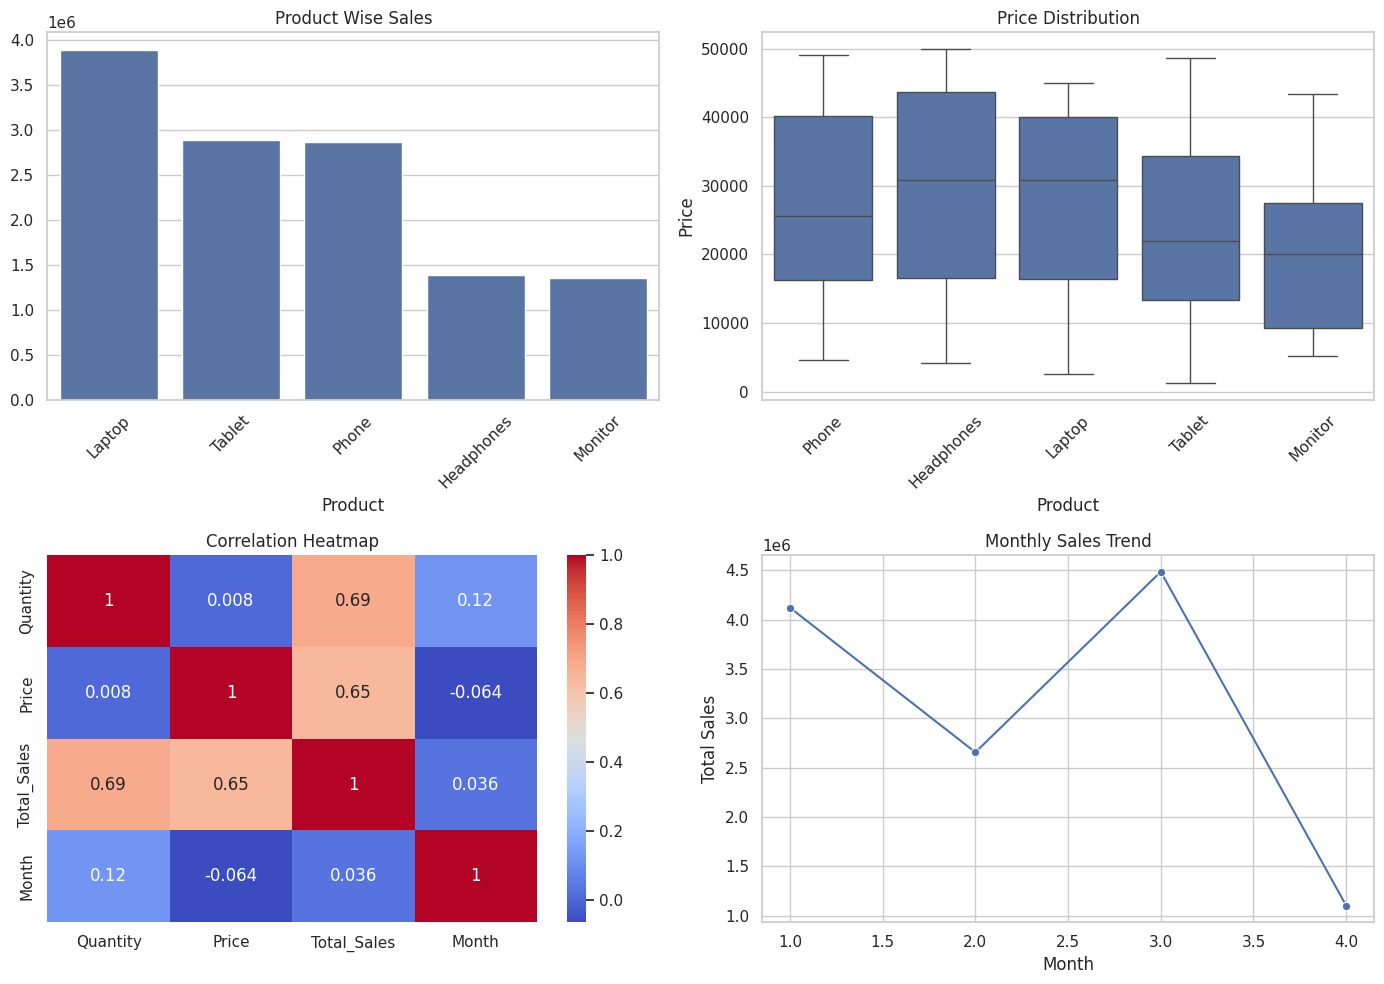

In [12]:
# Cell 12: 2x2 Dashboard Layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(x=product_sales.index, y=product_sales.values, ax=axes[0, 0])
axes[0, 0].set_title("Product Wise Sales")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.boxplot(x="Product", y="Price", data=df, ax=axes[0, 1])
axes[0, 1].set_title("Price Distribution")
axes[0, 1].tick_params(axis="x", rotation=45)

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", ax=axes[1, 0])
axes[1, 0].set_title("Correlation Heatmap")

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Monthly Sales Trend")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Total Sales")

plt.tight_layout()
plt.show()


In [13]:
# Cell 13: Interactive Plotly chart
fig = px.bar(
    df,
    x="Product",
    y="Total_Sales",
    color="Region",
    hover_data=["Date", "Quantity", "Price", "Customer_ID"],
    title="Interactive Product Sales Dashboard"
)

fig.show()

In [14]:
# Cell 14: Final dashboard report
print("=" * 60)
print("INTERACTIVE SALES DASHBOARD REPORT")
print("=" * 60)

print(f"Total Revenue        : ₹{total_revenue:,.2f}")
print(f"Average Sales Value  : ₹{average_sales:,.2f}")
print(f"Best Selling Product : {best_product}")
print(f"Top Performing Region: {best_region}")

print("=" * 60)

INTERACTIVE SALES DASHBOARD REPORT
Total Revenue        : ₹12,365,048.00
Average Sales Value  : ₹123,650.48
Best Selling Product : Laptop
Top Performing Region: North
